## Phần 1 - Thống kê mô tả & đặc trưng

**1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng số cột.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset("iris")

print("5 dòng đầu của dữ liệu:")
display(df.head())

print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
print("\nKiểu dữ liệu của các cột:")
print(df.dtypes)

5 dòng đầu của dữ liệu:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Số dòng: 150, Số cột: 5

Kiểu dữ liệu của các cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


**2. Tính các đại lượng thống kê cho mỗi biến số.**

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

stats_df = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'mode': df[numeric_cols].mode().iloc[0],
    'var': df[numeric_cols].var(),
    'std': df[numeric_cols].std(),
    'min': df[numeric_cols].min(),
    'max': df[numeric_cols].max(),
    'Q1': df[numeric_cols].quantile(0.25),
    'Q3': df[numeric_cols].quantile(0.75)
})
stats_df['IQR'] = stats_df['Q3'] - stats_df['Q1']

display(stats_df)

,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


**3. Dùng groupby tính mean và std của từng biến theo loài (species).**

In [3]:
grouped_stats = df.groupby('species')[numeric_cols].agg(['mean', 'std'])
display(grouped_stats)

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

**Nhận xét Phần 1:**

* Nhìn vào kết quả groupby, ta thấy nhóm **setosa** có sự khác biệt rõ rệt nhất so với hai nhóm còn lại (`versicolor` và `virginica`), đặc biệt là ở các đặc trưng `petal_length` và `petal_width` (giá trị trung bình nhỏ hơn rất nhiều và độ lệch chuẩn cũng thấp hơn).

---

## Phần 2 - Phân phối xác suất

**1. Vẽ histogram + KDE cho từng biến số.**

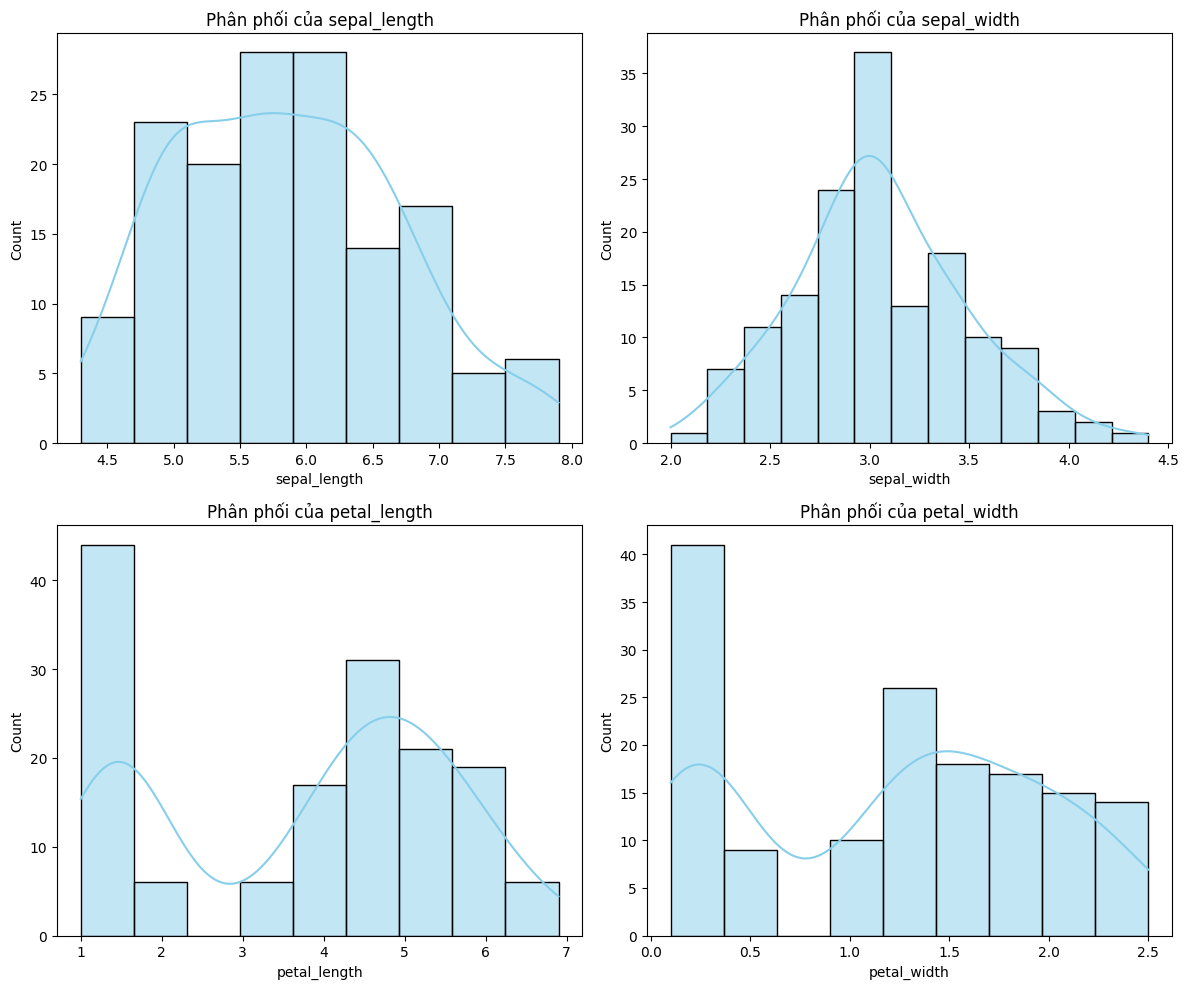

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Phân phối của {col}')

plt.tight_layout()
plt.show()

**Nhận xét về hình dạng phân phối:**

* **sepal_length & sepal_width:** Hình dạng phân phối dạng chuông, khá gần với phân phối chuẩn.
* **petal_length & petal_width:** Phân phối không chuẩn, có dạng hai đỉnh (bimodal) rõ rệt.

**2. Vẽ boxplot từng biến theo nhóm (species).**

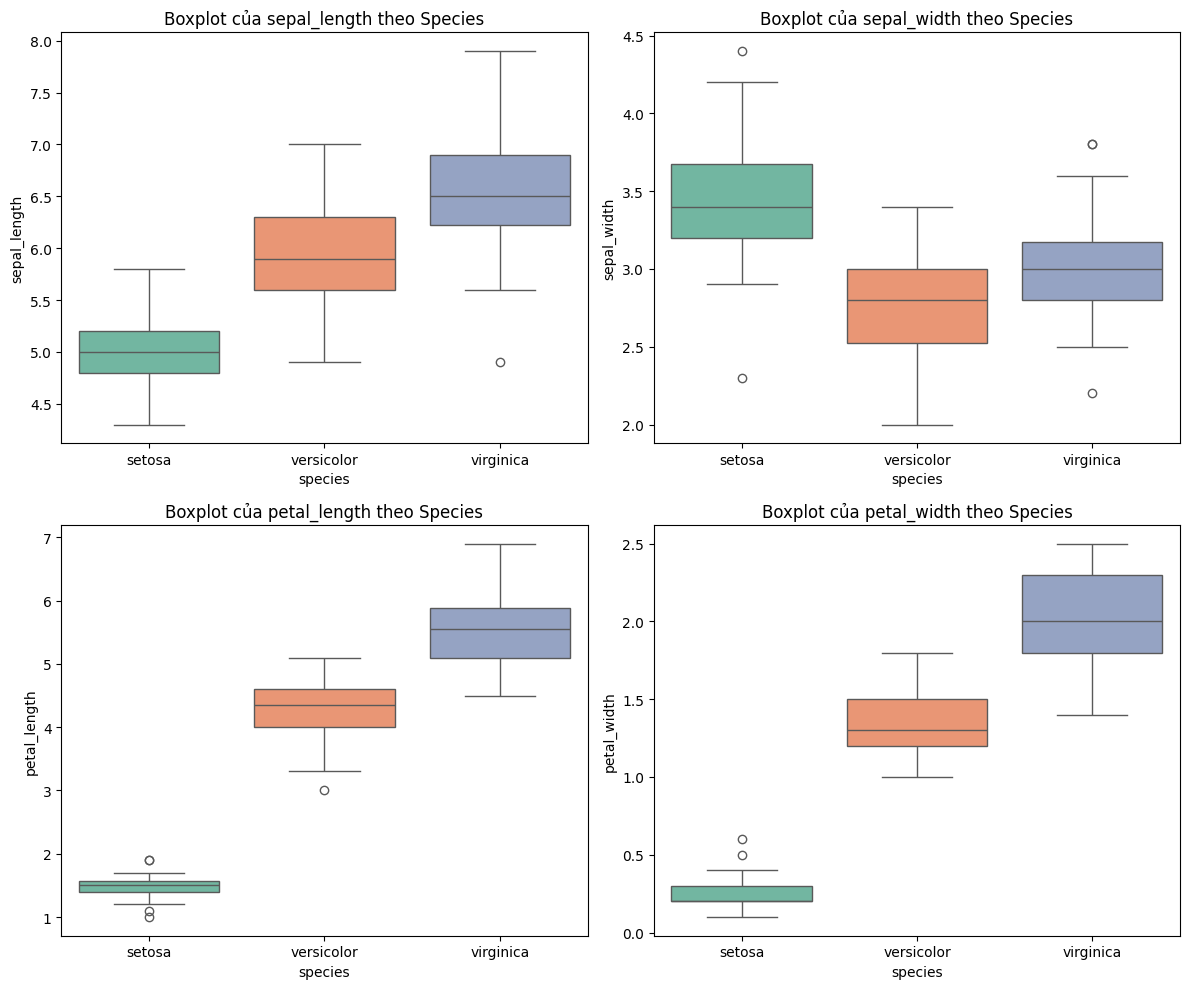

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='species', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Boxplot của {col} theo Species')

plt.tight_layout()
plt.show()

**3. Mô phỏng phân phối Normal và so sánh.**

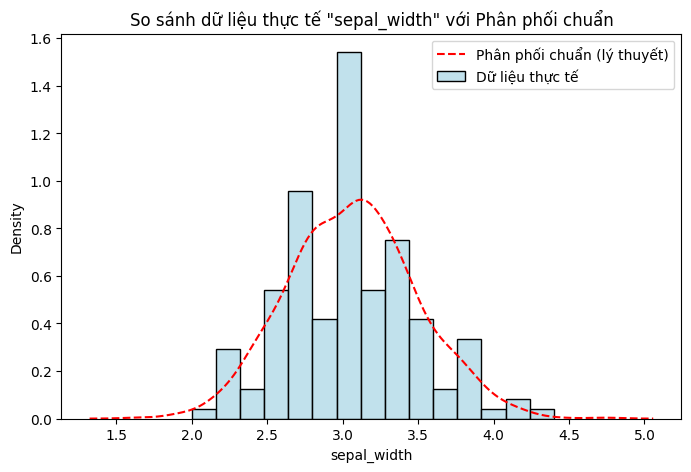

In [6]:
col_to_sim = 'sepal_width'
mean_val = df[col_to_sim].mean()
std_val = df[col_to_sim].std()

np.random.seed(42)
simulated_data = np.random.normal(mean_val, std_val, size=1000)

plt.figure(figsize=(8, 5))
sns.histplot(df[col_to_sim], kde=False, stat='density', label='Dữ liệu thực tế', color='lightblue', bins=15)
sns.kdeplot(simulated_data, label='Phân phối chuẩn (lý thuyết)', color='red', linestyle='--')

plt.title(f'So sánh dữ liệu thực tế "{col_to_sim}" với Phân phối chuẩn')
plt.legend()
plt.show()

## Phần 3 - Phân tích đa biến & tương quan

**1 & 2. Ma trận hiệp phương sai, tương quan và Heatmap.**

Ma trận hiệp phương sai (Covariance):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


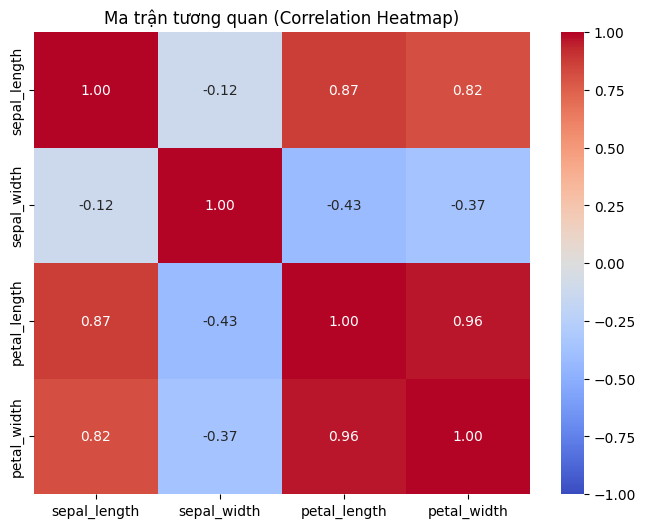

In [7]:
cov_matrix = df[numeric_cols].cov()
cor_matrix = df[numeric_cols].corr()

print("Ma trận hiệp phương sai (Covariance):")
display(cov_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Ma trận tương quan (Correlation Heatmap)")
plt.show()

## Phần 4 - Xác suất & Định lý Bayes

**1. Tính xác suất hậu nghiệm P(B|+).**

In [8]:
P_B = 0.01
P_not_B = 1 - P_B
P_pos_given_B = 0.99
P_pos_given_not_B = 0.05

P_pos = (P_pos_given_B * P_B) + (P_pos_given_not_B * P_not_B)
P_B_given_pos = (P_pos_given_B * P_B) / P_pos

print(f"Xác suất mắc bệnh P(B|+) là: {P_B_given_pos:.4f} ({P_B_given_pos*100:.2f}%)")

Xác suất mắc bệnh P(B|+) là: 0.1667 (16.67%)


**3. Bộ lọc Spam Naive Bayes**

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

train_emails = [
    "chúc mừng bạn nhận được phần thưởng tiền mặt",
    "bạn có rảnh chiều nay để họp dự án không",
    "bấm vào link để nhận thưởng tiền mặt ngay",
    "gửi tôi file báo cáo tiến độ nhé",
    "khuyến mãi sốc phần thưởng tiền mặt lớn"
]
y_train = ["spam", "ham", "spam", "ham", "spam"]

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(train_emails)

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

test_emails = [
    "họp xong nhớ gửi tôi tiền mặt nhé",
    "chúc mừng phần thưởng của bạn"
]
X_test_vec = vectorizer.transform(test_emails)

probs = nb_model.predict_proba(X_test_vec)
classes = nb_model.classes_

for i, email in enumerate(test_emails):
    print(f"Email: '{email}'")
    for j, class_name in enumerate(classes):
        print(f"  -> P({class_name} | email) = {probs[i][j]:.4f}")
    print("-" * 40)

Email: 'họp xong nhớ gửi tôi tiền mặt nhé'
  -> P(ham | email) = 0.6114
  -> P(spam | email) = 0.3886
----------------------------------------
Email: 'chúc mừng phần thưởng của bạn'
  -> P(ham | email) = 0.0276
  -> P(spam | email) = 0.9724
----------------------------------------
